# Field Detection and Camera Movement Analysis

This notebook analyzes football field detection using optical flow to track static field features and estimate camera movement.

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

## Load Test Images

Load consecutive frames from football footage to analyze field features and camera movement.

In [34]:
# Load video and extract frames with skipping
video_path = "/Users/alanpehz/Documents/Personal/True Computer Vision/FootballTracker/Videos/demo2.mp4"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps if fps > 0 else 30

print(f"Video info: {total_frames} frames, {fps:.1f} FPS, {duration:.1f}s duration")

# Skip every 5 frames to reduce processing while covering full video
frame_skip = 5
frames = []
frame_indices = []

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % frame_skip == 0:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
        frame_indices.append(frame_count)

    frame_count += 1

cap.release()

print(f"Loaded {len(frames)} frames (every {frame_skip}th frame)")
print(f"Frame shape: {frames[0].shape}")
print(f"Time coverage: 0s to {frame_indices[-1]/fps:.1f}s")


Video info: 750 frames, 25.0 FPS, 30.0s duration
Loaded 150 frames (every 5th frame)
Frame shape: (1080, 1920, 3)
Time coverage: 0s to 29.8s


## Field Feature Detection Setup

Configure parameters for detecting and tracking field features using Lucas-Kanade optical flow.

In [35]:
class FieldTracker:
    def __init__(self, frame_shape):
        self.minimum_distance = 5
        
        # Lucas-Kanade optical flow parameters
        self.lk_params = dict(
            winSize=(15, 15),
            maxLevel=2,
            criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
        )
        
        # Create mask for field edge detection
        mask_features = np.zeros((frame_shape[0], frame_shape[1]), dtype=np.uint8)
        mask_features[:, 0:20] = 1  # Left edge
        mask_features[:, frame_shape[1]-150:frame_shape[1]] = 1  # Right edge
        
        # Feature detection parameters
        self.features = dict(
            maxCorners=100,
            qualityLevel=0.3,
            minDistance=10,
            blockSize=7,
            mask=mask_features
        )
    
    def get_distance(self, p1, p2):
        return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    
    def detect_features(self, frame):
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        features = cv2.goodFeaturesToTrack(gray, **self.features)
        return gray, features
    
    def track_movement(self, old_gray, new_gray, old_features):
        new_features, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray, new_gray, old_features, None, **self.lk_params
        )
        
        max_distance = 0
        camera_movement_x, camera_movement_y = 0, 0
        
        for i, (new, old) in enumerate(zip(new_features, old_features)):
            if status[i] == 1:  # Feature successfully tracked
                new_point = new.ravel()
                old_point = old.ravel()
                
                distance = self.get_distance(new_point, old_point)
                
                if distance > max_distance:
                    max_distance = distance
                    camera_movement_x = new_point[0] - old_point[0]
                    camera_movement_y = new_point[1] - old_point[1]
        
        if max_distance > self.minimum_distance:
            return [camera_movement_x, camera_movement_y], new_features
        else:
            return [0, 0], old_features

## Visualize Feature Detection Mask

Show the mask used to focus on field edges where static features are most reliable.

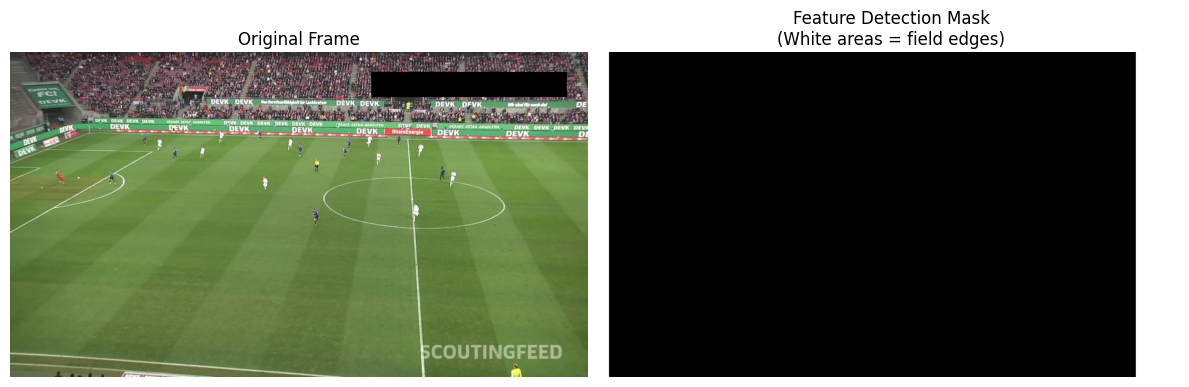

In [36]:
if frames:
    tracker = FieldTracker(frames[0].shape)
    
    # Visualize the mask
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(frames[0])
    plt.title('Original Frame')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(tracker.features['mask'], cmap='gray')
    plt.title('Feature Detection Mask\n(White areas = field edges)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Detect and Visualize Field Features

Extract corner features from the first frame that will be tracked across subsequent frames.

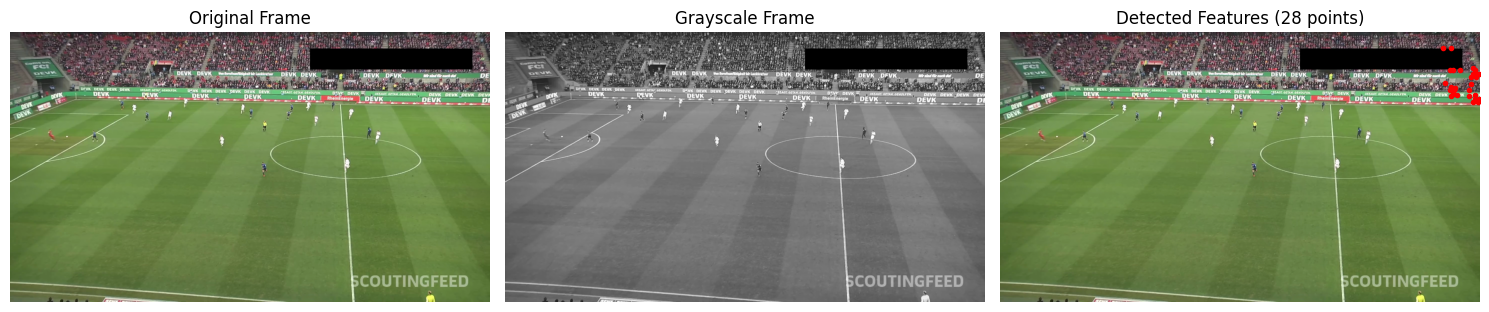

In [37]:
if frames:
    # Detect features in first frame
    gray_frame, features = tracker.detect_features(frames[0])
    
    # Visualize detected features
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(frames[0])
    plt.title('Original Frame')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gray_frame, cmap='gray')
    plt.title('Grayscale Frame')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(frames[0])
    if features is not None:
        for feature in features:
            x, y = feature.ravel()
            plt.plot(x, y, 'ro', markersize=3)
        plt.title(f'Detected Features ({len(features)} points)')
    else:
        plt.title('No Features Detected')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Track Camera Movement Between Frames

Use optical flow to track features and calculate camera movement between consecutive frames.

In [38]:
if len(frames) >= 2:
    camera_movements = []
    
    # Initialize with first frame
    old_gray, old_features = tracker.detect_features(frames[0])
    
    for i in range(1, len(frames)):
        # Get current frame
        new_gray = cv2.cvtColor(frames[i], cv2.COLOR_RGB2GRAY)
        
        # Track movement
        movement, new_features = tracker.track_movement(old_gray, new_gray, old_features)
        camera_movements.append(movement)
        
        print(f"Frame {i}: Camera movement = [{movement[0]:.2f}, {movement[1]:.2f}]")
        
        # Update for next iteration
        old_gray = new_gray
        old_features = new_features
    
    print(f"\nTotal camera movements detected: {len(camera_movements)}")

Frame 1: Camera movement = [-13.74, 0.56]
Frame 2: Camera movement = [-17.55, 9.48]
Frame 3: Camera movement = [10.54, 17.28]
Frame 4: Camera movement = [-4.99, 1.05]
Frame 5: Camera movement = [-17.74, 0.04]
Frame 6: Camera movement = [-11.67, -0.34]
Frame 7: Camera movement = [-7.83, 3.25]
Frame 8: Camera movement = [0.00, 0.00]
Frame 9: Camera movement = [81.10, 1.15]
Frame 10: Camera movement = [-19.27, 5.41]
Frame 11: Camera movement = [-22.72, 0.19]
Frame 12: Camera movement = [53.80, 7.82]
Frame 13: Camera movement = [0.00, 0.00]
Frame 14: Camera movement = [0.00, 0.00]
Frame 15: Camera movement = [0.00, 0.00]
Frame 16: Camera movement = [0.00, 0.00]
Frame 17: Camera movement = [0.00, 0.00]
Frame 18: Camera movement = [0.00, 0.00]
Frame 19: Camera movement = [0.00, 0.00]
Frame 20: Camera movement = [0.00, 0.00]
Frame 21: Camera movement = [0.00, 0.00]
Frame 22: Camera movement = [0.00, 0.00]
Frame 23: Camera movement = [0.00, 0.00]
Frame 24: Camera movement = [0.00, 0.00]
Frame 

## Visualize Feature Tracking

Show how features move between frames to illustrate camera movement detection.

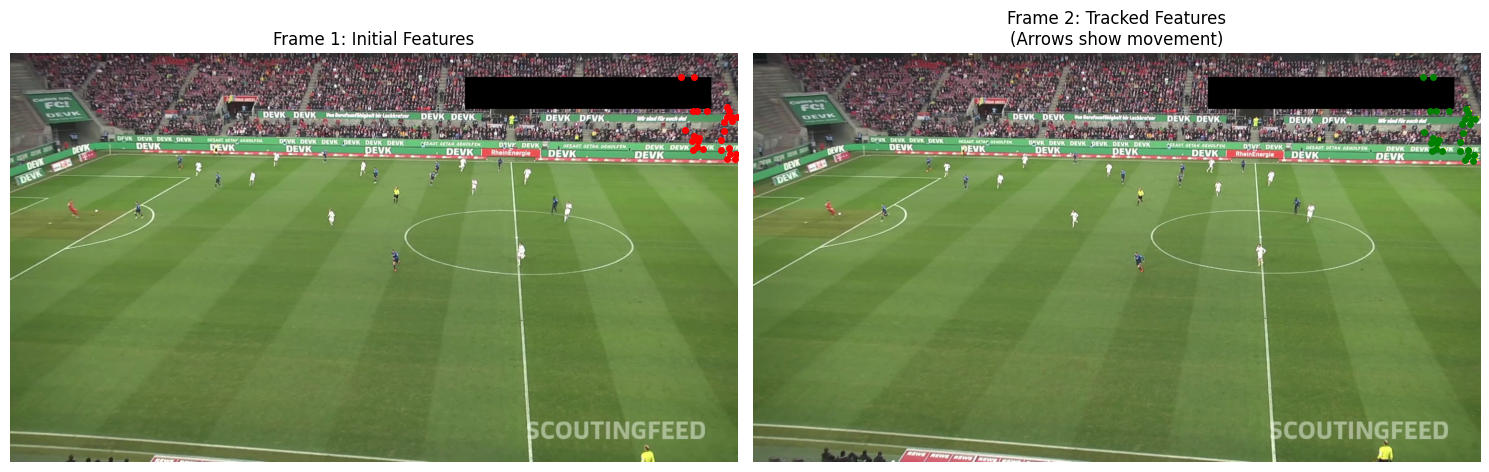

Successfully tracked 28 out of 28 features


In [39]:
if len(frames) >= 2:
    # Track features between first two frames for visualization
    gray1 = cv2.cvtColor(frames[0], cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(frames[1], cv2.COLOR_RGB2GRAY)
    
    features1 = cv2.goodFeaturesToTrack(gray1, **tracker.features)
    
    if features1 is not None:
        features2, status, error = cv2.calcOpticalFlowPyrLK(
            gray1, gray2, features1, None, **tracker.lk_params
        )
        
        # Create visualization
        plt.figure(figsize=(15, 6))
        
        plt.subplot(1, 2, 1)
        plt.imshow(frames[0])
        for feature in features1:
            x, y = feature.ravel()
            plt.plot(x, y, 'ro', markersize=4)
        plt.title('Frame 1: Initial Features')
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(frames[1])
        
        # Draw feature tracking vectors
        good_features1 = features1[status == 1]
        good_features2 = features2[status == 1]
        
        for i, (f1, f2) in enumerate(zip(good_features1, good_features2)):
            x1, y1 = f1.ravel()
            x2, y2 = f2.ravel()
            
            plt.plot(x2, y2, 'go', markersize=4)
            plt.arrow(x1, y1, x2-x1, y2-y1, head_width=5, head_length=5, 
                     fc='yellow', ec='yellow', alpha=0.7)
        
        plt.title('Frame 2: Tracked Features\n(Arrows show movement)')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Successfully tracked {len(good_features1)} out of {len(features1)} features")

## Camera Movement Analysis

Analyze the detected camera movements and their patterns.

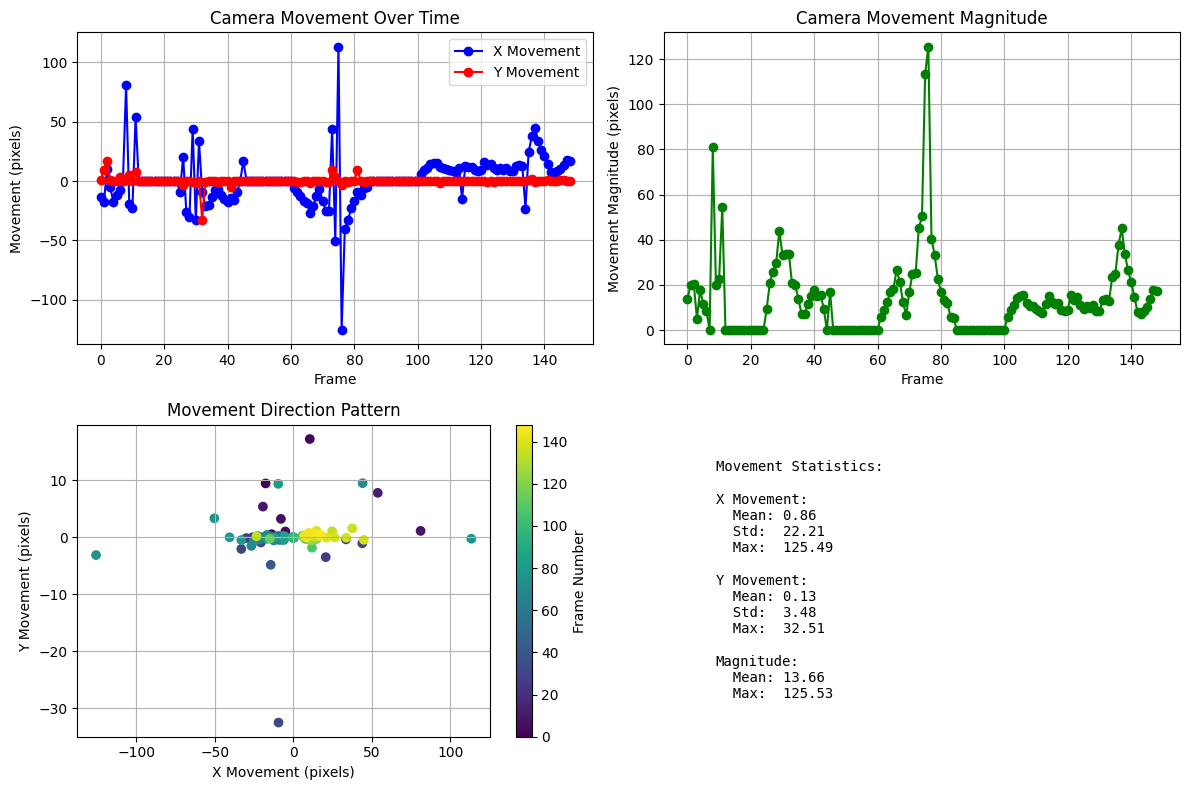

In [40]:
if camera_movements:
    movements_array = np.array(camera_movements)
    
    plt.figure(figsize=(12, 8))
    
    # Plot X and Y movements over time
    plt.subplot(2, 2, 1)
    plt.plot(movements_array[:, 0], 'b-o', label='X Movement')
    plt.plot(movements_array[:, 1], 'r-o', label='Y Movement')
    plt.xlabel('Frame')
    plt.ylabel('Movement (pixels)')
    plt.title('Camera Movement Over Time')
    plt.legend()
    plt.grid(True)
    
    # Movement magnitude
    plt.subplot(2, 2, 2)
    magnitudes = np.sqrt(movements_array[:, 0]**2 + movements_array[:, 1]**2)
    plt.plot(magnitudes, 'g-o')
    plt.xlabel('Frame')
    plt.ylabel('Movement Magnitude (pixels)')
    plt.title('Camera Movement Magnitude')
    plt.grid(True)
    
    # Movement direction (2D plot)
    plt.subplot(2, 2, 3)
    plt.scatter(movements_array[:, 0], movements_array[:, 1], c=range(len(movements_array)), cmap='viridis')
    plt.xlabel('X Movement (pixels)')
    plt.ylabel('Y Movement (pixels)')
    plt.title('Movement Direction Pattern')
    plt.colorbar(label='Frame Number')
    plt.grid(True)
    
    # Statistics
    plt.subplot(2, 2, 4)
    stats_text = f"""Movement Statistics:
    
X Movement:
  Mean: {np.mean(movements_array[:, 0]):.2f}
  Std:  {np.std(movements_array[:, 0]):.2f}
  Max:  {np.max(np.abs(movements_array[:, 0])):.2f}

Y Movement:
  Mean: {np.mean(movements_array[:, 1]):.2f}
  Std:  {np.std(movements_array[:, 1]):.2f}
  Max:  {np.max(np.abs(movements_array[:, 1])):.2f}

Magnitude:
  Mean: {np.mean(magnitudes):.2f}
  Max:  {np.max(magnitudes):.2f}"""
    
    plt.text(0.1, 0.5, stats_text, transform=plt.gca().transAxes, 
             fontsize=10, verticalalignment='center', fontfamily='monospace')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Field Edge Analysis

Analyze the effectiveness of focusing on field edges for camera movement detection.

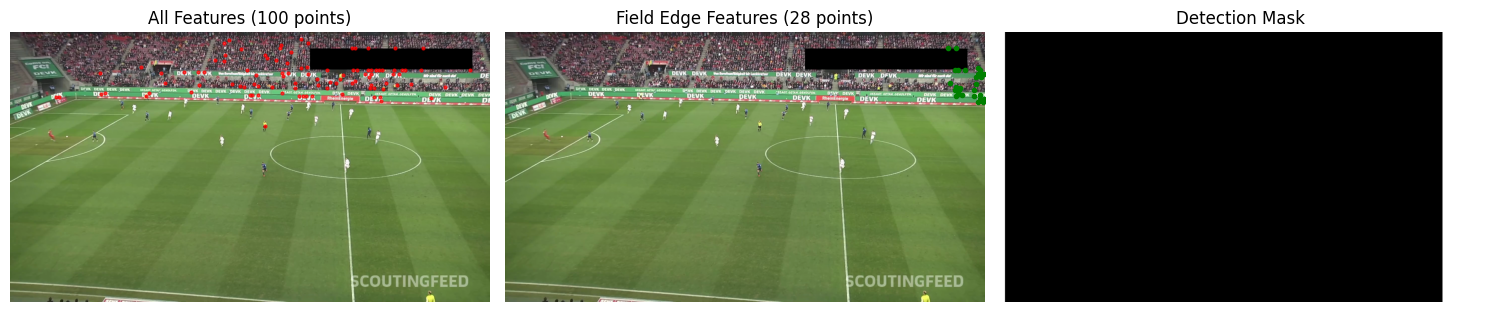

Features detected:
  - Full image: 100
  - Field edges only: 28

Field edge approach focuses on 28.0% of total features


In [41]:
if frames:
    # Compare feature detection with and without mask
    gray = cv2.cvtColor(frames[0], cv2.COLOR_RGB2GRAY)
    
    # Features with mask (field edges only)
    features_masked = cv2.goodFeaturesToTrack(gray, **tracker.features)
    
    # Features without mask (entire image)
    features_full = cv2.goodFeaturesToTrack(gray, 
                                           maxCorners=100,
                                           qualityLevel=0.3,
                                           minDistance=10,
                                           blockSize=7)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(frames[0])
    if features_full is not None:
        for feature in features_full:
            x, y = feature.ravel()
            plt.plot(x, y, 'ro', markersize=2, alpha=0.7)
        plt.title(f'All Features ({len(features_full)} points)')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(frames[0])
    if features_masked is not None:
        for feature in features_masked:
            x, y = feature.ravel()
            plt.plot(x, y, 'go', markersize=3)
        plt.title(f'Field Edge Features ({len(features_masked)} points)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(tracker.features['mask'], cmap='gray')
    plt.title('Detection Mask')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Features detected:")
    print(f"  - Full image: {len(features_full) if features_full is not None else 0}")
    print(f"  - Field edges only: {len(features_masked) if features_masked is not None else 0}")
    print(f"\nField edge approach focuses on {len(features_masked)/len(features_full)*100:.1f}% of total features")

## Frame Comparison - Highest Movement Detection

Compare
frames
with highest camera movement to validate the tracking algorithm.

Frames with highest camera movement:
Frame 77: Movement = 125.53 pixels at 15.4s
Frame 76: Movement = 113.37 pixels at 15.2s
Frame 9: Movement = 81.10 pixels at 1.8s
Frame 12: Movement = 54.37 pixels at 2.4s
Frame 75: Movement = 50.29 pixels at 15.0s


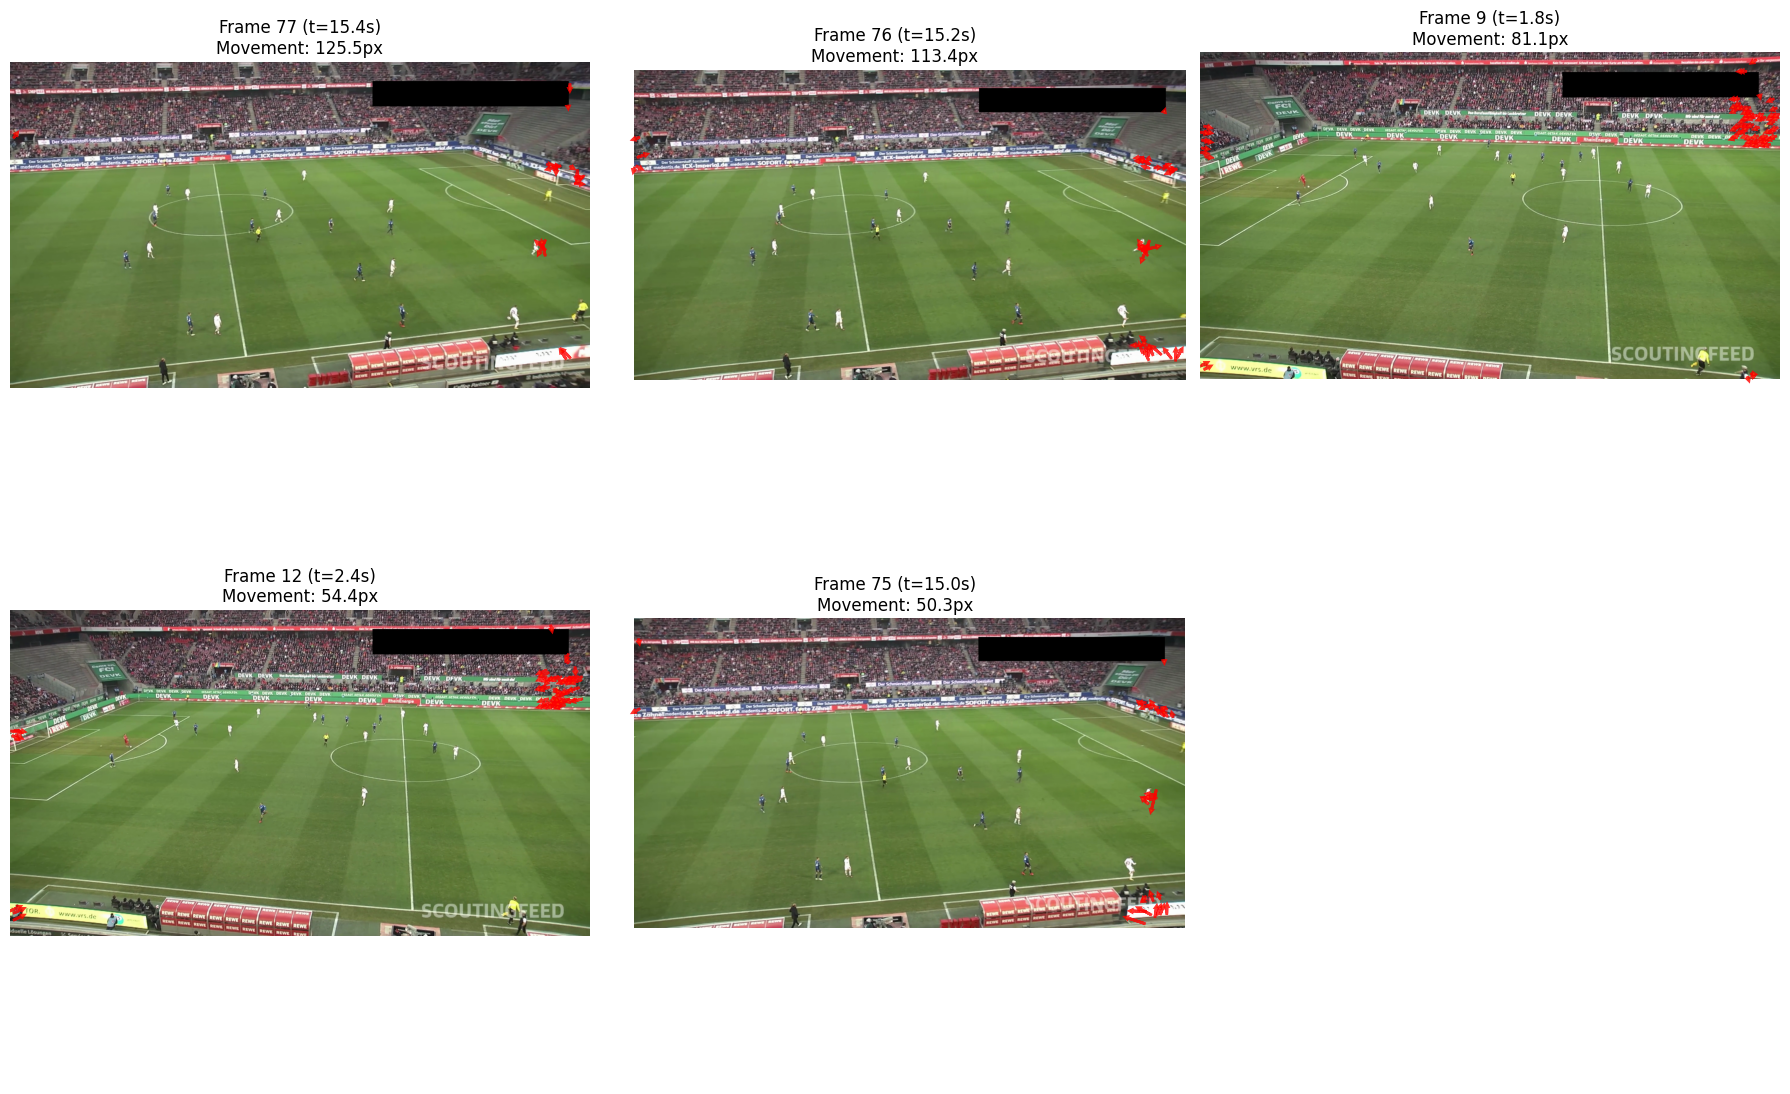

In [42]:
if camera_movements:
    movements_array = np.array(camera_movements)
    magnitudes = np.sqrt(movements_array[:, 0] ** 2 + movements_array[:, 1] ** 2)

    # Find frames with highest movement
    top_movement_indices = np.argsort(magnitudes)[-5:]  # Top 5 movements

    print("Frames with highest camera movement:")
    for idx in reversed(top_movement_indices):
        frame_time = frame_indices[idx + 1] / fps
        print(f"Frame {idx + 1}: Movement = {magnitudes[idx]:.2f} pixels at {frame_time:.1f}s")

    # Visualize top movement frames
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, idx in enumerate(reversed(top_movement_indices)):
        if i < 5:  # Show top 5
            # Track features between consecutive frames
            gray1 = cv2.cvtColor(frames[idx], cv2.COLOR_RGB2GRAY)
            gray2 = cv2.cvtColor(frames[idx + 1], cv2.COLOR_RGB2GRAY)

            features1 = cv2.goodFeaturesToTrack(gray1, **tracker.features)

            if features1 is not None:
                features2, status, error = cv2.calcOpticalFlowPyrLK(
                    gray1, gray2, features1, None, **tracker.lk_params
                )

                # Show frame with movement vectors
                axes[i].imshow(frames[idx + 1])

                good_features1 = features1[status == 1]
                good_features2 = features2[status == 1]

                for f1, f2 in zip(good_features1, good_features2):
                    x1, y1 = f1.ravel()
                    x2, y2 = f2.ravel()
                    axes[i].arrow(x1, y1, x2 - x1, y2 - y1, head_width=8, head_length=8,
                                  fc='yellow', ec='red', alpha=0.8, linewidth=2)

                frame_time = frame_indices[idx + 1] / fps
                axes[i].set_title(f'Frame {idx + 1} (t={frame_time:.1f}s)\nMovement: {magnitudes[idx]:.1f}px')
                axes[i].axis('off')

    # Hide unused subplot
    axes[5].axis('off')
    plt.tight_layout()
    plt.show()

## Long-term Movement Comparison

Compare
frames
with large time gaps to see cumulative camera movement effects.

Gap 0.0s to 7.4s: 22/28 features tracked, avg movement: 44.1px
Gap 0.0s to 15.0s: 20/28 features tracked, avg movement: 40.2px
Gap 0.0s to 22.4s: 20/28 features tracked, avg movement: 42.6px
Gap 0.0s to 29.8s: 19/28 features tracked, avg movement: 41.3px


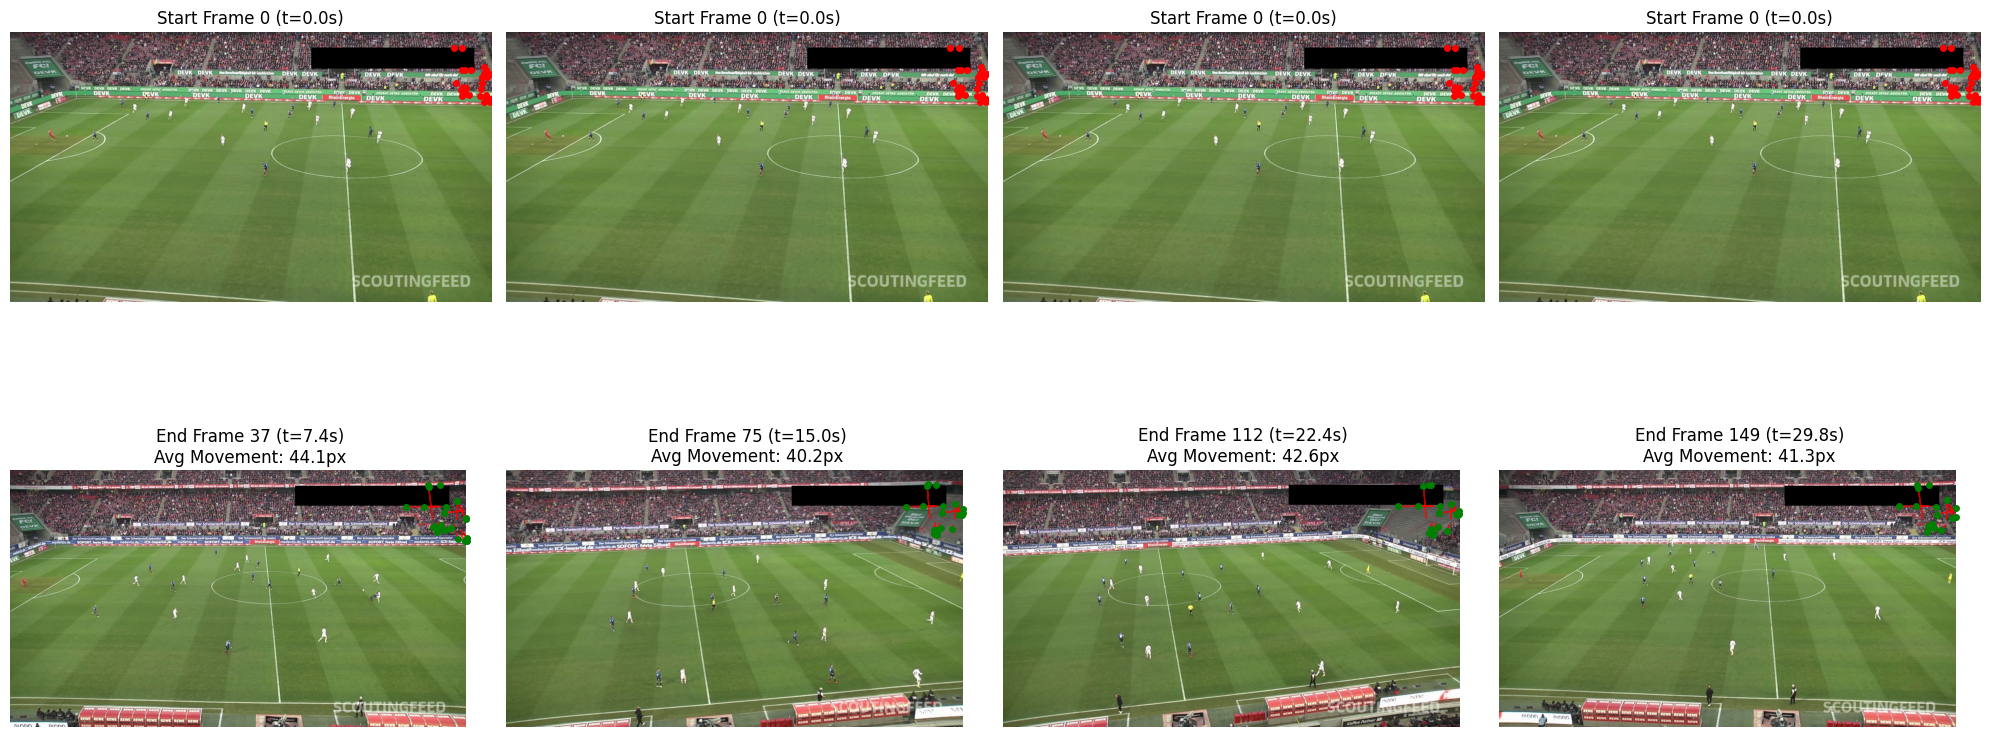

In [43]:
if len(frames) > 10:
    # Compare frames with large gaps
    comparison_pairs = [
        (0, len(frames) // 4),  # Start to 25%
        (0, len(frames) // 2),  # Start to 50%
        (0, 3 * len(frames) // 4),  # Start to 75%
        (0, len(frames) - 1)  # Start to end
    ]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for i, (start_idx, end_idx) in enumerate(comparison_pairs):
        # Track features across large gap
        gray1 = cv2.cvtColor(frames[start_idx], cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(frames[end_idx], cv2.COLOR_RGB2GRAY)

        features1 = cv2.goodFeaturesToTrack(gray1, **tracker.features)

        if features1 is not None:
            features2, status, error = cv2.calcOpticalFlowPyrLK(
                gray1, gray2, features1, None, **tracker.lk_params
            )

            # Show start frame
            axes[0, i].imshow(frames[start_idx])
            for feature in features1:
                x, y = feature.ravel()
                axes[0, i].plot(x, y, 'ro', markersize=4)

            start_time = frame_indices[start_idx] / fps
            axes[0, i].set_title(f'Start Frame {start_idx} (t={start_time:.1f}s)')
            axes[0, i].axis('off')

            # Show end frame with tracking
            axes[1, i].imshow(frames[end_idx])

            good_features1 = features1[status == 1]
            good_features2 = features2[status == 1]

            total_movement = 0
            for f1, f2 in zip(good_features1, good_features2):
                x1, y1 = f1.ravel()
                x2, y2 = f2.ravel()
                axes[1, i].plot(x2, y2, 'go', markersize=4)
                axes[1, i].arrow(x1, y1, x2 - x1, y2 - y1, head_width=8, head_length=8,
                                 fc='yellow', ec='red', alpha=0.7, linewidth=1)
                total_movement += np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            avg_movement = total_movement / len(good_features1) if len(good_features1) > 0 else 0
            end_time = frame_indices[end_idx] / fps
            axes[1, i].set_title(f'End Frame {end_idx} (t={end_time:.1f}s)\nAvg Movement: {avg_movement:.1f}px')
            axes[1, i].axis('off')

            print(
                f"Gap {start_time:.1f}s to {end_time:.1f}s: {len(good_features1)}/{len(features1)} features tracked, avg movement: {avg_movement:.1f}px")

    plt.tight_layout()
    plt.show()

In [48]:
# === Annotated Motion Visualization (Optical Flow Vector + Contours) ===
import cv2
import numpy as np

output_path = "annotated_output.mp4"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

ret, old_frame = cap.read()
if not ret:
    raise RuntimeError("Could not read first frame")

tracker = FieldTracker(old_frame.shape)
old_rgb = cv2.cvtColor(old_frame, cv2.COLOR_BGR2RGB)
old_gray, old_features = tracker.detect_features(old_rgb)

# --- Helper: draw text with transparent background ---
def draw_text_box(frame, text, pos, font_scale=0.8, color=(255,255,255),
                  bg_color=(0,0,0), thickness=2, alpha=0.5):
    (tw, th), base = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    x, y = pos
    overlay = frame.copy()
    cv2.rectangle(overlay, (x, y - th - 8), (x + tw + 10, y + base + 6), bg_color, -1)
    cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)
    cv2.putText(frame, text, (x + 5, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, thickness)

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    new_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    new_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if old_features is None:
        old_gray, old_features = tracker.detect_features(new_rgb)
        continue

    # Track motion using optical flow
    movement, new_features = tracker.track_movement(old_gray, new_gray, old_features)
    mx, my = movement

    # Motion mask for contour visualization (frame differencing)
    diff = cv2.absdiff(old_gray, new_gray)
    _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
    thresh = cv2.dilate(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        if cv2.contourArea(contour) < 500:
            continue
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Draw red arrow showing average movement vector
    center = (width // 2, height // 2)
    arrow_tip = (int(center[0] + mx * 10), int(center[1] + my * 10))
    cv2.arrowedLine(frame, center, arrow_tip, (0, 0, 255), 3, tipLength=0.3)

    # Draw readable text overlays
    draw_text_box(frame, f"Frame: {frame_idx}", (20, 40))
    draw_text_box(frame, f"Movement vector: ({mx:.2f}, {my:.2f})", (20, 80))

    out.write(frame)

    # Update for next iteration
    old_gray = new_gray.copy()
    old_features = new_features
    frame_idx += 1

cap.release()
out.release()
print(f"✅ Annotated video with contours and motion vector saved to: {output_path}")


✅ Annotated video with contours and motion vector saved to: annotated_output.mp4


## Conclusion

This analysis demonstrates how field detection works for camera movement estimation:

1. **Feature Mask**: Focuses on field edges where static elements (lines, boundaries) are most reliable
2. **Optical Flow**: Tracks these features between frames using Lucas-Kanade method
3. **Movement Calculation**: Determines camera displacement from feature movement patterns
4. **Filtering**: Only considers movements above minimum threshold to avoid noise

The key insight is that by tracking static field elements rather than dynamic objects (players, ball), we can accurately detect and compensate for camera movement in football footage.